# DeiT-Small from Scratch — Facial Emotion Recognition
Was sent and got : 539


## 0 — Install dependencies

In [1]:
%%capture
!pip install timm --quiet

## 1 — Configuration


In [ ]:
# -- Dataset paths ----------------------------------------------------------
TRAIN_DIR          = "/kaggle/input/competitions/emotion-detection-competition/Training_data/Training_data"
TEST_DIR           = "/kaggle/input/competitions/emotion-detection-competition/test/test"
SUBMISSION_TEMPLATE= "/kaggle/input/datasets/ahmedmohamed6/test-1"
OUTPUT_DIR         = "/kaggle/working"

# Extra datasets
EXTRA_DIRS = [

    "/kaggle/input/datasets/sudarshanvaidya/corrective-reannotation-of-fer-ck-kdef/fer_ckplus_kdef",


    "/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data",


    "/kaggle/input/datasets/samithsachidanandan/human-face-emotions/Data",
]
CAP_RATIO          = 2.0

# Model
MODEL_VARIANT      = 'small'

# Training hyperparameters
EPOCHS             = 300
BATCH_SIZE         = 128
LEARNING_RATE      = 5e-4
WEIGHT_DECAY       = 0.05
WARMUP_EPOCHS      = 25
LABEL_SMOOTHING    = 0.1
MIXUP_ALPHA        = 0.4
CUTMIX_ALPHA       = 0.4
MIXUP_PROB         = 0.3
RANDAUGMENT_N      = 2
RANDAUGMENT_M      = 5
SWA_EPOCHS         = 25
USE_TTA            = True
NUM_WORKERS        = 4

#Image config
IMG_SIZE           = 96
PATCH_SIZE         = 8
IN_CHANNELS        = 1      # Grayscale


FER_MEAN           = (0.5515,)
FER_STD            = (0.2451,)

# Class labels
LABELS = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'sad': 4, 'surprise': 5}
IDX_TO_LABEL = {v: k for k, v in LABELS.items()}
NUM_CLASSES = len(LABELS)

# Resume from checkpoint
RESUME_FROM        = None
RESUME_EPOCH       = 0

print("Configuration loaded.")
print(f"  Model variant : DeiT-{MODEL_VARIANT.capitalize()}")
print(f"  Image size    : {IMG_SIZE}x{IMG_SIZE} px, {IN_CHANNELS}-channel (grayscale)")
print(f"  Patch grid    : {IMG_SIZE//PATCH_SIZE}x{IMG_SIZE//PATCH_SIZE} = {(IMG_SIZE//PATCH_SIZE)**2} tokens")
print(f"  Epochs        : {EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LEARNING_RATE}")
print(f"  Extra dirs    : {len(EXTRA_DIRS)} source(s)")


## 2 — Imports

In [ ]:
import os
import math
import re
import json
import copy
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f"Device : {device}")
print(f"GPUs   : {n_gpus}")
for i in range(n_gpus):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {props.name}  {props.total_memory/1e9:.1f} GB")


print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if not torch.cuda.is_available():
    print("WARNING: No GPU detected! Go to Settings → Accelerator → GPU T4 x2")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## 3 — DeiT Architecture

In [ ]:

# 1 Patch Embedding
class PatchEmbedding(nn.Module):

    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.num_patches = (img_size // patch_size) ** 2
        self.projection  = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size, bias=True
        )

    def forward(self, x):
        x = self.projection(x)   # (B, D, H/P, W/P)
        x = x.flatten(2)         # (B, D, N)
        x = x.transpose(1, 2)    # (B, N, D)
        return x


#2 Multi-Head Self Attention
class MultiHeadSelfAttention(nn.Module):

    def __init__(self, embed_dim, num_heads, attn_dropout=0.0, proj_dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, embed_dim * 3, bias=True)
        self.proj      = nn.Linear(embed_dim, embed_dim, bias=True)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj_drop = nn.Dropout(proj_dropout)

    def forward(self, x):
        B, L, D = x.shape
        # Fused QKV: (B,L,D) → (B,L,3D) → (3,B,H,L,d)
        qkv = self.qkv(x).reshape(B, L, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)                        # each (B,H,L,d)
        attn = (q @ k.transpose(-2,-1)) * self.scale   # (B,H,L,L)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1,2).contiguous().reshape(B, L, D)  # (B,L,D)
        return self.proj_drop(self.proj(x))


#3 MLP Block
class MLP(nn.Module):

    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden = int(embed_dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


#4 Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):

    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0,
                 attn_dropout=0.0, proj_dropout=0.0, mlp_dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, attn_dropout, proj_dropout)
        self.norm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.mlp   = MLP(embed_dim, mlp_ratio, mlp_dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


#5 DeiT Model
class DeiTScratch(nn.Module):

    CONFIGS = {
        'tiny':  dict(embed_dim=192, depth=12, num_heads=3),
        'small': dict(embed_dim=384, depth=12, num_heads=6),
        'base':  dict(embed_dim=768, depth=12, num_heads=12),
    }

    def __init__(self, variant='small', num_classes=6,
                 img_size=96, patch_size=8, in_channels=1,
                 mlp_ratio=4.0, drop_rate=0.0, attn_drop_rate=0.0):
        super().__init__()
        cfg = self.CONFIGS[variant]
        D   = cfg['embed_dim']
        self.num_tokens = 2   # CLS + DIST

        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, D)
        N = self.patch_embed.num_patches   # 144 for 96px/patch8

        # Learnable special tokens — start at zero, learned by backprop
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, D))
        self.dist_token = nn.Parameter(torch.zeros(1, 1, D))

        # Positional embeddings — one per position in [CLS, DIST, patch_1...patch_N]
        self.pos_embed  = nn.Parameter(torch.zeros(1, N + self.num_tokens, D))
        self.pos_drop   = nn.Dropout(drop_rate)

        # Transformer encoder
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                D, cfg['num_heads'], mlp_ratio,
                attn_dropout=attn_drop_rate,
                proj_dropout=drop_rate,
                mlp_dropout=drop_rate,
            )
            for _ in range(cfg['depth'])
        ])
        self.norm = nn.LayerNorm(D, eps=1e-6)

        # Classification heads
        self.classifier = nn.Linear(D, num_classes)
        self.dist_head  = nn.Linear(D, num_classes)

        self._init_weights()
        n_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"DeiT-{variant.capitalize()} built: {n_params/1e6:.1f}M parameters")

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed,  std=0.02)
        nn.init.trunc_normal_(self.cls_token,  std=0.02)
        nn.init.trunc_normal_(self.dist_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, pixel_values):
        B = pixel_values.shape[0]

        # 1 Patch tokens: (B,C,H,W) → (B,N,D)
        x = self.patch_embed(pixel_values)

        # 2 Prepend CLS and DIST tokens: (B,N+2,D)
        cls_tokens  = self.cls_token.expand(B, -1, -1)
        dist_tokens = self.dist_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, dist_tokens, x], dim=1)

        # 3 Add positional embeddings and apply dropout
        x = self.pos_drop(x + self.pos_embed)

        # 4 Pass through all transformer blocks (shape unchanged)
        for block in self.blocks:
            x = block(x)

        # 5 Final LayerNorm
        x = self.norm(x)

        # 6 Extract special token representations
        cls_out  = x[:, 0]   # (B, D)
        dist_out = x[:, 1]   # (B, D)

        # 7 Classification heads
        cls_logits  = self.classifier(cls_out)   # (B, num_classes)
        dist_logits = self.dist_head(dist_out)   # (B, num_classes)

        if self.training:
            logits = cls_logits
        else:
            logits = (cls_logits + dist_logits) / 2.0


        return logits

print("Architecture defined.")

def get_logits(output):
    return output.logits


## 4 — Dataset & Transforms

In [ ]:
import hashlib
import threading
from collections import defaultdict, Counter


def make_train_transforms():
    pad = max(11, IMG_SIZE // 9)
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE + pad, IMG_SIZE + pad)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandAugment(num_ops=RANDAUGMENT_N, magnitude=RANDAUGMENT_M),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.1, scale=(0.02, 0.06), ratio=(0.3, 3.3), value=0),
        transforms.Normalize(mean=FER_MEAN, std=FER_STD),
    ])


def make_val_transforms():
    resize = int(IMG_SIZE * 256 / 224)
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(resize),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=FER_MEAN, std=FER_STD),
    ])


def make_tta_transforms():
    resize = int(IMG_SIZE * 256 / 224)
    normalize = transforms.Normalize(mean=FER_MEAN, std=FER_STD)
    gray  = transforms.Grayscale(num_output_channels=1)
    base  = [gray, transforms.Resize(resize), transforms.CenterCrop(IMG_SIZE),
             transforms.ToTensor(), normalize]
    flip  = [gray, transforms.Resize(resize), transforms.CenterCrop(IMG_SIZE),
             transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), normalize]
    crop1 = [gray, transforms.Resize(IMG_SIZE + 10), transforms.CenterCrop(IMG_SIZE),
             transforms.ToTensor(), normalize]
    crop2 = [gray, transforms.Resize(IMG_SIZE + 10), transforms.CenterCrop(IMG_SIZE),
             transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), normalize]
    return [transforms.Compose(t) for t in [base, flip, crop1, crop2]]


def _hash_file(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read(8192))
    return h.hexdigest()


def _hash_files_parallel(paths, n_threads=8):
    results = {}
    lock = threading.Lock()
    def worker(chunk):
        local = {p: _hash_file(p) for p in chunk}
        with lock:
            results.update(local)
    chunk_size = max(1, len(paths) // n_threads)
    chunks = [paths[i:i + chunk_size] for i in range(0, len(paths), chunk_size)]
    threads = [threading.Thread(target=worker, args=(c,)) for c in chunks]
    for t in threads: t.start()
    for t in threads: t.join()
    return results


class EmotionDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples   = []
        root = Path(root)
        for label_name, label_idx in LABELS.items():
            folder = root / label_name
            if not folder.exists():
                raise ValueError(f"Missing folder: {folder}")
            for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
                for p in sorted(folder.glob(ext)):
                    self.samples.append((str(p), label_idx))
        print(f"[EmotionDataset] {len(self.samples)} images from {root}")

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label, path


# Aliases to normalise variant folder names found in some datasets
FOLDER_ALIASES = {
    "anger":     "angry",
    "happiness": "happy",
    "sadness":   "sad",
    "fearful":   "fear",
    "disgusted": "disgust",
    "surprised": "surprise",
}

class ExtraEmotionDataset(Dataset):

    def __init__(self, extra_dirs, transform=None):
        self.transform = transform
        self.samples   = []
        self.class_counts = defaultdict(int)
        for root in extra_dirs:
            root = Path(root)
            if not root.exists():
                print(f"[ExtraEmotionDataset] WARNING: {root} not found -- skipping")
                continue
            for folder in sorted(root.iterdir()):
                if not folder.is_dir(): continue
                raw_name   = folder.name.lower().strip()
                label_name = FOLDER_ALIASES.get(raw_name, raw_name)
                if label_name not in LABELS:
                    print(f"  '{folder.name}' -> '{label_name}' -- SKIPPED (not in LABELS)")
                    continue
                label_idx = LABELS[label_name]
                before = len(self.samples)
                for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
                    for p in sorted(folder.glob(ext)):
                        self.samples.append((str(p), label_idx))
                added = len(self.samples) - before
                self.class_counts[label_name] += added
                print(f"  '{folder.name}' -> '{label_name}' (label {label_idx}) [{added} images]")
        print(f"[ExtraEmotionDataset] Total loaded: {len(self.samples)} samples")

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label, path


class EmotionDatasetTest(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples   = []
        root = Path(root)
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
            self.samples.extend(sorted(root.glob(ext)))
        if not self.samples:
            for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
                self.samples.extend(sorted(root.rglob(ext)))
        self.samples = [str(p) for p in self.samples]
        print(f"[TestDataset] {len(self.samples)} images from {root}")

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path = self.samples[idx]
        img  = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, -1, path


def _dedup_extras(orig_samples, extra_samples, n_threads=8):

    print(f"[dedup] Hashing {len(orig_samples)} orig + {len(extra_samples)} extras ...")
    orig_hashes  = _hash_files_parallel([s[0] for s in orig_samples],  n_threads)
    extra_hashes = _hash_files_parallel([s[0] for s in extra_samples], n_threads)
    seen = set(orig_hashes.values())
    kept, extra_seen = [], set()
    dupes = 0
    for s in extra_samples:
        h = extra_hashes[s[0]]
        if h in seen or h in extra_seen:
            dupes += 1
        else:
            kept.append(s)
            extra_seen.add(h)
    print(f"[dedup] Removed {dupes} duplicates -> {len(kept)} extras kept")
    return kept


def build_loaders():

    # 1 Original dataset
    orig_ds = EmotionDataset(TRAIN_DIR, transform=None)
    orig_samples = orig_ds.samples

    # 2 Extra datasets
    extra_samples = []
    if EXTRA_DIRS:
        extra_ds = ExtraEmotionDataset(EXTRA_DIRS, transform=None)
        extra_samples = extra_ds.samples

    # 3 Deduplicate
    if extra_samples:
        extra_samples = _dedup_extras(orig_samples, extra_samples)

    # 4 Cap per class
    if extra_samples and CAP_RATIO is not None:
        orig_class_counts = Counter(s[1] for s in orig_samples)
        per_class = defaultdict(list)
        for s in extra_samples:
            per_class[s[1]].append(s)
        capped = []
        for label_idx, items in per_class.items():
            cap = int(CAP_RATIO * orig_class_counts.get(label_idx, 0))
            random.shuffle(items)
            capped.extend(items[:cap])
        extra_samples = capped
        print(f"[extras-cap] After cap (ratio={CAP_RATIO}): {len(extra_samples)} extras kept")

    # 5. Stratified 90/10 split on originals only
    class_indices = defaultdict(list)
    for i, (_, label) in enumerate(orig_samples):
        class_indices[label].append(i)
    train_orig_idx, val_idx = [], []
    for label, indices in class_indices.items():
        random.shuffle(indices)
        split = int(0.9 * len(indices))
        train_orig_idx.extend(indices[:split])
        val_idx.extend(indices[split:])

    # 6 Class weights on combined training set
    all_train_labels = ([orig_samples[i][1] for i in train_orig_idx]
                        + [s[1] for s in extra_samples])
    label_counts = Counter(all_train_labels)
    total        = sum(label_counts.values())
    class_weights = torch.tensor(
        [total / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)],
        dtype=torch.float32
    ).to(device)
    print(f"[build_loaders] Class weights: { {IDX_TO_LABEL[i]: f'{class_weights[i].item():.3f}' for i in range(NUM_CLASSES)} }")

    train_transform = make_train_transforms()
    val_transform   = make_val_transforms()

    class SubsetWithTransform(Dataset):
        def __init__(self, base_samples, indices, transform):
            self.base_samples = base_samples
            self.indices      = indices
            self.transform    = transform
        def __len__(self): return len(self.indices)
        def __getitem__(self, idx):
            path, label = self.base_samples[self.indices[idx]]
            img = Image.open(path).convert("RGB")
            if self.transform: img = self.transform(img)
            return img, label, path

    class ListDataset(Dataset):
        def __init__(self, samples, transform):
            self.samples   = samples
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            path, label = self.samples[idx]
            img = Image.open(path).convert("RGB")
            if self.transform: img = self.transform(img)
            return img, label, path

    train_orig_ds = SubsetWithTransform(orig_samples, train_orig_idx, train_transform)
    val_ds        = SubsetWithTransform(orig_samples, val_idx,        val_transform)
    test_ds       = EmotionDatasetTest(TEST_DIR, transform=val_transform)

    if extra_samples:
        from torch.utils.data import ConcatDataset
        train_ds = ConcatDataset([train_orig_ds, ListDataset(extra_samples, train_transform)])
    else:
        train_ds = train_orig_ds

    loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                         pin_memory=True, persistent_workers=(NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, shuffle=True,  **loader_kwargs)
    val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kwargs)
    test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kwargs)

    print(f"\n[build_loaders] Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"[build_loaders] Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
    return train_loader, val_loader, test_loader, class_weights


print("Dataset utilities defined.")


## 5 — MixUp / CutMix

In [ ]:
class MixupCutmix:

    def __init__(self, num_classes, alpha_mix=0.4, alpha_cut=0.4, prob=0.3):
        self.num_classes = num_classes
        self.alpha_mix   = alpha_mix
        self.alpha_cut   = alpha_cut
        self.prob        = prob

    def __call__(self, images, labels):
        if random.random() > self.prob:
            return images, F.one_hot(labels, self.num_classes).float()

        use_cutmix = random.random() > 0.5
        alpha      = self.alpha_cut if use_cutmix else self.alpha_mix
        lam        = np.random.beta(alpha, alpha)
        B          = images.size(0)
        idx        = torch.randperm(B, device=images.device)

        if use_cutmix:
            _, _, H, W = images.shape
            cut_ratio  = math.sqrt(1 - lam)
            cut_h      = int(H * cut_ratio)
            cut_w      = int(W * cut_ratio)
            cx         = random.randint(0, W)
            cy         = random.randint(0, H)
            x1 = max(cx - cut_w // 2, 0);  x2 = min(cx + cut_w // 2, W)
            y1 = max(cy - cut_h // 2, 0);  y2 = min(cy + cut_h // 2, H)
            images = images.clone()
            images[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
            lam = 1 - (x2-x1)*(y2-y1) / (H*W)
        else:
            images = lam * images + (1 - lam) * images[idx]

        labels_a = F.one_hot(labels,      self.num_classes).float()
        labels_b = F.one_hot(labels[idx], self.num_classes).float()
        soft_labels = lam * labels_a + (1 - lam) * labels_b
        return images, soft_labels

print("MixUp/CutMix defined.")

## 6 — Loss, Scheduler, Trainer

In [7]:
class LabelSmoothingCrossEntropy(nn.Module):

    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)

        # Soft targets from MixUp/CutMix
        if targets.dim() == 2:
            smooth_targets = (
                targets * (1 - self.smoothing) +
                self.smoothing / n_classes
            )
            loss = -(smooth_targets * log_probs).sum(dim=-1)  # (B,)
            if self.weight is not None:
                hard_class = targets.argmax(dim=-1)
                loss = loss * self.weight[hard_class]
        else:
            # Hard labels
            smooth_targets = torch.full_like(log_probs, self.smoothing / n_classes)
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1 - self.smoothing + self.smoothing / n_classes)
            loss = -(smooth_targets * log_probs).sum(dim=-1)  # (B,)
            if self.weight is not None:
                loss = loss * self.weight[targets]

        return loss.mean()


class WarmupCosineScheduler:

    def __init__(self, optimizer, warmup_epochs, total_epochs, base_lr):
        self.optimizer      = optimizer
        self.warmup_epochs  = warmup_epochs
        self.total_epochs   = total_epochs
        self.base_lr        = base_lr

    def step(self, epoch):   # epoch is 1-indexed
        if epoch <= self.warmup_epochs:
            lr = self.base_lr * epoch / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.base_lr * 0.5 * (1 + math.cos(math.pi * progress))
        for g in self.optimizer.param_groups:
            g['lr'] = lr
        return lr


def train_one_epoch(model, loader, optimizer, loss_fn, scaler, mixup_fn):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels, _ in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        images, soft_labels = mixup_fn(images, labels)

        with torch.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
            logits = get_logits(model(images))
            loss   = loss_fn(logits, soft_labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # gradient clipping
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        total_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, loss_fn):

    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
            logits = get_logits(model(images))
            loss   = loss_fn(logits, labels)
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


print("Loss, scheduler, training loop defined.")

Loss, scheduler, training loop defined.


## 7 — Build model & dataloaders

In [ ]:
# Build dataloaders
train_loader, val_loader, test_loader, class_weights = build_loaders()

# Build model
model = DeiTScratch(
    variant=MODEL_VARIANT,
    num_classes=NUM_CLASSES,
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
).to(device)

# Use DataParallel if multiple GPUs available
if n_gpus > 1:
    model = nn.DataParallel(model)
    print(f"Using DataParallel across {n_gpus} GPUs")

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler
scheduler = WarmupCosineScheduler(optimizer, WARMUP_EPOCHS, EPOCHS, LEARNING_RATE)

# Loss
loss_fn  = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING, weight=class_weights)
val_loss_fn = LabelSmoothingCrossEntropy(smoothing=0.0, weight=None)  # clean val loss

# MixUp/CutMix
mixup_fn = MixupCutmix(NUM_CLASSES, MIXUP_ALPHA, CUTMIX_ALPHA, MIXUP_PROB)

# AMP scaler
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

print(f"\nReady to train for {EPOCHS} epochs.")
print(f"Effective batch size: {BATCH_SIZE} (no gradient accumulation needed on Kaggle)")

# Resume from checkpoint
if RESUME_FROM is not None:
    import os
    if os.path.exists(RESUME_FROM):
        print(f"\nLoading checkpoint from: {RESUME_FROM}")
        ckpt = torch.load(RESUME_FROM, map_location=device)
        # Load into the model (unwrap DataParallel if needed)
        target = model.module if hasattr(model, 'module') else model
        target.load_state_dict(ckpt)
        print(f"Checkpoint loaded successfully.")
        print(f"Will continue training from epoch {RESUME_EPOCH + 1} / {EPOCHS}")
    else:
        raise FileNotFoundError(f"Checkpoint not found at: {RESUME_FROM}")
else:
    print("No checkpoint specified — training from scratch.")


## 8 — Training loop

In [9]:
history    = []
best_acc   = 0.0
best_state = None
swa_states = []
swa_start  = EPOCHS - SWA_EPOCHS + 1

for epoch in range(RESUME_EPOCH + 1, EPOCHS + 1):
    lr = scheduler.step(epoch)

    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler, mixup_fn)
    val_loss, val_acc = evaluate(model, val_loader, val_loss_fn)

    # Save best checkpoint
    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = copy.deepcopy(
            model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        )
        torch.save(best_state, f'{OUTPUT_DIR}/best_model.pt')

    # Collect SWA snapshots
    if epoch >= swa_start:
        snap = copy.deepcopy(
            model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        )
        swa_states.append(snap)
        print(f"  SWA snapshot {len(swa_states)}/{SWA_EPOCHS} taken")

    record = {'epoch': epoch, 'train_loss': train_loss,
              'val_loss': val_loss, 'val_acc': val_acc, 'lr': lr}
    history.append(record)
    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"train={train_loss:.4f}  val={val_loss:.4f}  "
          f"acc={val_acc:.4f}  lr={lr:.2e}  best={best_acc:.4f}")

# Save training history
with open(f'{OUTPUT_DIR}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f"\nTraining complete. Best val_acc: {best_acc:.4f}")

Training:   0%|          | 0/655 [00:00<?, ?it/s]

Epoch   1/300  train=1.7755  val=1.9123  acc=0.2944  lr=2.00e-05  best=0.2944


Training:   0%|          | 0/655 [00:00<?, ?it/s]

Epoch   2/300  train=1.7094  val=1.8866  acc=0.2911  lr=4.00e-05  best=0.2944


Training:   0%|          | 0/655 [00:00<?, ?it/s]

...

  SWA snapshot 23/25 taken
Epoch 298/300  train=0.6101  val=0.7173  acc=0.8917  lr=6.53e-08  best=0.8935


Training:   0%|          | 0/655 [00:00<?, ?it/s]

  SWA snapshot 24/25 taken
Epoch 299/300  train=0.6381  val=0.7173  acc=0.8920  lr=1.63e-08  best=0.8935


Training:   0%|          | 0/655 [00:00<?, ?it/s]

  SWA snapshot 25/25 taken
Epoch 300/300  train=0.6239  val=0.7173  acc=0.8920  lr=0.00e+00  best=0.8935

Training complete. Best val_acc: 0.8935


## 9 — SWA: average last N epoch weights

In [10]:
# Guard: if SWA_EPOCHS > EPOCHS, swa_states will be empty
if not swa_states:
    print("WARNING: No SWA snapshots collected. SWA_EPOCHS may exceed EPOCHS.")
    print("Using best single-epoch checkpoint instead.")
    final_model = DeiTScratch(
        variant=MODEL_VARIANT, num_classes=NUM_CLASSES,
        img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS,
    ).to(device)
    final_model.load_state_dict(best_state)
    torch.save(best_state, f'{OUTPUT_DIR}/swa_model.pt')  # save best as swa for consistency
else:
    # Average all SWA snapshots into a single weight set
    swa_state = {}
    for key in swa_states[0].keys():
        swa_state[key] = torch.stack([s[key].float() for s in swa_states]).mean(0)
    
    # Load SWA weights and evaluate
    eval_model = DeiTScratch(
        variant=MODEL_VARIANT, num_classes=NUM_CLASSES,
        img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS,
    ).to(device)
    eval_model.load_state_dict(swa_state)
    
    swa_val_loss, swa_val_acc = evaluate(eval_model, val_loader, val_loss_fn)
    print(f"SWA ({len(swa_states)} snapshots): val_acc={swa_val_acc:.4f}  val_loss={swa_val_loss:.4f}")
    print(f"Best single epoch:                 val_acc={best_acc:.4f}")
    
    # Use whichever is better
    if swa_val_acc >= best_acc:
        final_model = eval_model
        print("Using SWA weights for prediction.")
    else:
        final_model = DeiTScratch(
            variant=MODEL_VARIANT, num_classes=NUM_CLASSES,
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS,
        ).to(device)
        final_model.load_state_dict(best_state)
        print("Using best single-epoch weights for prediction.")
    
    torch.save(swa_state, f'{OUTPUT_DIR}/swa_model.pt')

DeiT-Small built: 21.4M parameters
SWA (25 snapshots): val_acc=0.8905  val_loss=0.7174
Best single epoch:                 val_acc=0.8935
DeiT-Small built: 21.4M parameters
Using best single-epoch weights for prediction.


## 10 — TTA Prediction & Submission

In [11]:
@torch.no_grad()
def predict_tta(model, test_dir, batch_size=64):

    model.eval()
    tta_transforms = make_tta_transforms()
    all_logits = None
    all_paths  = None

    for tta_idx, tf in enumerate(tta_transforms):
        ds     = EmotionDatasetTest(test_dir, transform=tf)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
        batch_logits = []
        batch_paths  = []
        for images, _, paths in tqdm(loader, desc=f'TTA {tta_idx+1}/{len(tta_transforms)}'):
            images = images.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                logits = get_logits(model(images))
            batch_logits.append(logits.cpu().float())
            batch_paths.extend(paths)

        epoch_logits = torch.cat(batch_logits, dim=0)   # (N, num_classes)
        if all_logits is None:
            all_logits = epoch_logits
            all_paths  = batch_paths
        else:
            all_logits += epoch_logits

    # Average logits over TTA views → softmax probabilities → argmax
    avg_logits   = all_logits / len(tta_transforms)
    all_probs    = torch.softmax(avg_logits, dim=1).numpy()   # (N, num_classes)
    pred_indices = avg_logits.argmax(dim=1).tolist()          # (N,)
    pred_labels  = [IDX_TO_LABEL[i] for i in pred_indices]   # (N,) label strings
    return all_paths, pred_labels, all_probs


def save_submission(paths, pred_labels, probs, output_dir):

    output_dir = Path(output_dir)

    # Extract filename without extension as the ID
    ids = []
    for p in paths:
        match = re.search(r'[^\\/]+(?=\.\w+$)', p)
        ids.append(match.group() if match else Path(p).stem)

    # Main submission CSV
    df = pd.DataFrame({'filename': ids, 'label': pred_labels})
    submission_path = output_dir / 'submission.csv'
    df.to_csv(submission_path, index=False)
    print(f"Submission saved  : {submission_path}")
    print(f"Total predictions : {len(df)}")

    # Probability CSV for ensembling
    class_cols  = [IDX_TO_LABEL[i] for i in range(NUM_CLASSES)]
    df_probs    = pd.DataFrame(probs, columns=class_cols)
    df_probs.insert(0, 'filename', ids)
    probs_path  = output_dir / 'submission_probs.csv'
    df_probs.to_csv(probs_path, index=False)
    print(f"Probabilities saved: {probs_path}")

    return df


# Run TTA prediction
print("Running TTA prediction on test set...")
all_paths, pred_labels, all_probs = predict_tta(final_model, TEST_DIR, batch_size=64)

# Save outputs
df = save_submission(all_paths, pred_labels, all_probs, OUTPUT_DIR)

# Show prediction distribution
print("\nPrediction distribution:")
print(df['label'].value_counts())
print("\nFirst 10 predictions:")
print(df.head(10))

Running TTA prediction on test set...
[TestDataset] 7116 images from /kaggle/input/competitions/emotion-detection-competition/test/test


TTA 1/4:   0%|          | 0/112 [00:00<?, ?it/s]

[TestDataset] 7116 images from /kaggle/input/competitions/emotion-detection-competition/test/test


TTA 2/4:   0%|          | 0/112 [00:00<?, ?it/s]

[TestDataset] 7116 images from /kaggle/input/competitions/emotion-detection-competition/test/test


TTA 3/4:   0%|          | 0/112 [00:00<?, ?it/s]

[TestDataset] 7116 images from /kaggle/input/competitions/emotion-detection-competition/test/test


TTA 4/4:   0%|          | 0/112 [00:00<?, ?it/s]

Submission saved  : /kaggle/working/submission.csv
Total predictions : 7116
Probabilities saved: /kaggle/working/submission_probs.csv

Prediction distribution:
label
happy       1727
sad         1435
disgust     1020
fear        1013
angry        998
surprise     923
Name: count, dtype: int64

First 10 predictions:
      filename  label
0     test (1)  angry
1    test (10)    sad
2   test (100)    sad
3  test (1000)  happy
4  test (1001)  angry
5  test (1002)  angry
6  test (1003)  happy
7  test (1004)    sad
8  test (1005)   fear
9  test (1006)    sad


## 11 — Plot training history

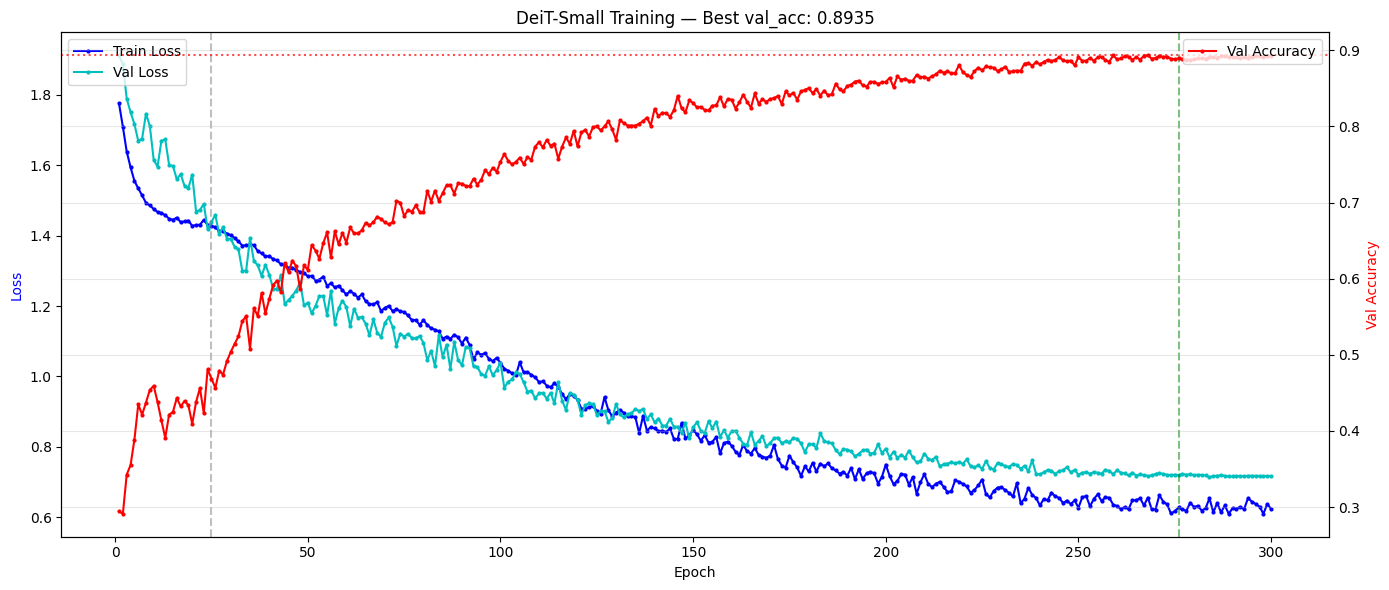

Plot saved to /kaggle/working/training_history.png


In [12]:
epochs     = [h['epoch']     for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss   = [h['val_loss']   for h in history]
val_acc    = [h['val_acc']    for h in history]

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(epochs, train_loss, 'b-o', markersize=2, label='Train Loss')
ax1.plot(epochs, val_loss,   'c-o', markersize=2, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')
ax1.legend(loc='upper left')
ax1.axvline(x=WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='Warmup end')
ax1.axvline(x=swa_start, color='green', linestyle='--', alpha=0.5, label='SWA start')

ax2 = ax1.twinx()
ax2.plot(epochs, val_acc, 'r-o', markersize=2, label='Val Accuracy')
ax2.set_ylabel('Val Accuracy', color='red')
ax2.legend(loc='upper right')
ax2.axhline(y=best_acc, color='red', linestyle=':', alpha=0.7, label=f'Best: {best_acc:.3f}')

plt.title(f'DeiT-{MODEL_VARIANT.capitalize()} Training — Best val_acc: {best_acc:.4f}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=150)
plt.show()
print(f"Plot saved to {OUTPUT_DIR}/training_history.png")

## 12 — Output files summary

After running all cells, `/kaggle/working/` contains:

| File | Description |
|---|---|
| `submission.csv` | Final predictions — submit this |
| `best_model.pt` | Best single-epoch weights |
| `swa_model.pt` | SWA-averaged weights |
| `training_history.json` | Full epoch-by-epoch metrics |
| `training_history.png` | Loss/accuracy plot |

To submit: go to **Competition → Submit Predictions → Upload** `submission.csv`.

In [13]:
import shutil, os

output_dir = "/kaggle/working"
zip_base   = os.path.join(output_dir, "key_outputs")

# Only zip the key output files rather than the entire working directory.
# Zipping /kaggle/working itself can fail with "no space left on device"
# because the zip is written into the same directory being archived.
key_files = [
    "submission.csv",
    "best_model.pt",
    "swa_model.pt",
    "training_history.json",
]

tmp_dir = os.path.join(output_dir, "_zip_tmp")
os.makedirs(tmp_dir, exist_ok=True)

found = []
for fname in key_files:
    src = os.path.join(output_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(tmp_dir, fname))
        found.append(fname)
    else:
        print(f"  [skip] {fname} not found")

if found:
    shutil.make_archive(zip_base, "zip", tmp_dir)
    shutil.rmtree(tmp_dir)
    zip_path = zip_base + ".zip"
    size_mb  = os.path.getsize(zip_path) / 1e6
    print(f"Created {zip_path}  ({size_mb:.1f} MB)")
    print("Files included:", found)
    print("Download key_outputs.zip from the Output tab!")
else:
    shutil.rmtree(tmp_dir)
    print("No output files found -- did training complete?")


Created /kaggle/working/key_outputs.zip  (159.0 MB)
Files included: ['submission.csv', 'best_model.pt', 'swa_model.pt', 'training_history.json']
Download key_outputs.zip from the Output tab!
